# Проект: вариант 1

Представьте, что вы работаете в компании, которая разрабатывает мобильные игры. К вам пришел менеджер с рядом задач по исследованию нескольких аспектов мобильного приложения:

В первую очередь, его интересует показатель retention. Напишите функцию для его подсчета.
Помимо этого, в компании провели A/B тестирование наборов акционных предложений. На основе имеющихся данных определите, какой набор можно считать лучшим и на основе каких метрик стоит принять правильное решение.
Предложите метрики для оценки результатов последнего прошедшего тематического события в игре.

# Задание 1
Retention – один из самых важных показателей в компании. Ваша задача – написать функцию, которая будет считать retention игроков (по дням от даты регистрации игрока). Данные лежат в папке shared и имеют следующую структуру:

In [98]:
import pandas as pd
import seaborn as sns
import scipy.stats as stats
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors
import numpy as np



In [2]:
df_reg = pd.read_csv('~/shared/problem1-reg_data.csv', sep=';')
df_auth = pd.read_csv('~/shared/problem1-auth_data.csv', sep=';')


In [3]:
df_reg.isna().sum()

reg_ts    0
uid       0
dtype: int64

In [4]:
df_auth.isna().sum()

auth_ts    0
uid        0
dtype: int64

In [5]:
df_reg.shape

(1000000, 2)

In [6]:
df_auth.shape

(9601013, 2)

In [7]:
df_reg.nunique()

reg_ts    1000000
uid       1000000
dtype: int64

In [8]:
1000000 < 9601013 

True

In [9]:
df_auth.groupby('uid', as_index=False) \
    .agg({'auth_ts': 'count'}) \
    .sort_values(by='auth_ts', ascending=False)

,uid,auth_ts
1,2,1929
99,108,1397
148,158,1367
163,176,1331
175,191,1296
...,...,...
379033,420829,1
379034,420830,1
379036,420832,1
379039,420835,1


In [10]:
# Как мы видим регистрации все уникальные и есть пользователи, которые возвращаются в игру

In [11]:
df1 = df_auth.merge(df_reg, on='uid', how='left')

In [12]:
df1 = df1[['uid', 'reg_ts', 'auth_ts']]

In [13]:
df1

,uid,reg_ts,auth_ts
0,1,911382223,911382223
1,2,932683089,932683089
2,2,932683089,932921206
3,2,932683089,933393015
4,2,932683089,933875379
...,...,...,...
9601008,1110618,1600874034,1600874034
9601009,1110619,1600874086,1600874086
9601010,1110620,1600874139,1600874139
9601011,1110621,1600874191,1600874191


In [14]:
df1['reg_date'] = pd.to_datetime(df1['reg_ts'], unit='s')
df1['auth_date'] = pd.to_datetime(df1['auth_ts'], unit='s')

In [15]:
df1['reg_year'] = df1['reg_date'].dt.to_period('Y')
df1['auth_year'] = df1['auth_date'].dt.to_period('Y')

In [95]:
df_year_reg = df1.groupby('reg_year', as_index=False) \
    .agg({'uid': 'count'})

In [96]:
df_auth_year = df1.groupby('auth_year', as_index=False) \
    .agg({'uid': 'count'})

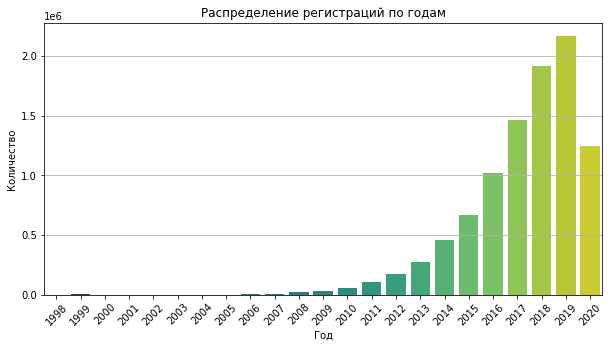

In [18]:

plt.figure(figsize=(10, 5))
sns.barplot(x='reg_year', y='uid', data=df_year_reg, palette='viridis')

plt.xticks(rotation=45)
plt.title('Распределение регистраций по годам')
plt.xlabel('Год')
plt.ylabel('Количество')
plt.grid(axis='y')

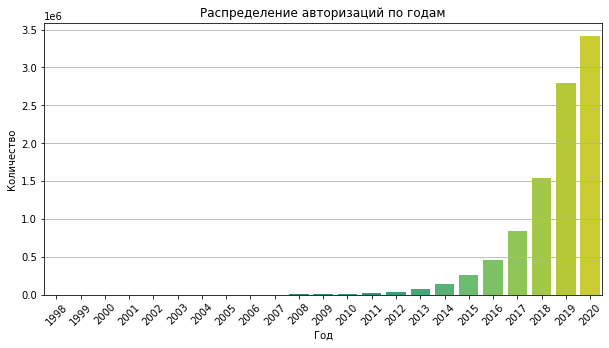

In [19]:

plt.figure(figsize=(10, 5))
sns.barplot(x='auth_year', y='uid', data=df_auth_year, palette='viridis')

plt.xticks(rotation=45)
plt.title('Распределение авторизаций по годам')
plt.xlabel('Год')
plt.ylabel('Количество')
plt.grid(axis='y')

In [20]:
# Перед написанием функции проведем тест
# посмотрим ретеншен за 2019 по месяцам

In [21]:
start_date = "2019-01-01"
end_date = "2019-12-31"

In [22]:
data_test = df1

In [23]:
data_test['reg_month'] = pd.to_datetime(data_test['reg_ts'], unit='s').dt.to_period('M') 

In [24]:
# Добавим количество месяцев со дня регистрации
data_test['count_months_reg'] = ((data_test.auth_date - data_test.reg_date) / np.timedelta64(1, 'M')).astype(int)

In [25]:
data_sort = data_test.query('reg_date >= @start_date and auth_date <= @end_date')
data_sort

,uid,reg_ts,auth_ts,reg_date,auth_date,reg_year,auth_year,reg_month,count_months_reg
3383865,393071,1546300835,1546300835,2019-01-01 00:00:35,2019-01-01 00:00:35,2019,2019,2019-01,0
3383873,393073,1546300983,1546300983,2019-01-01 00:03:03,2019-01-01 00:03:03,2019,2019,2019-01,0
3383880,393074,1546301131,1546301131,2019-01-01 00:05:31,2019-01-01 00:05:31,2019,2019,2019-01,0
3383887,393075,1546301280,1546301280,2019-01-01 00:08:00,2019-01-01 00:08:00,2019,2019,2019-01,0
3383895,393076,1546301428,1546301428,2019-01-01 00:10:28,2019-01-01 00:10:28,2019,2019,2019-01,0
...,...,...,...,...,...,...,...,...,...
6173315,715148,1577750302,1577750302,2019-12-30 23:58:22,2019-12-30 23:58:22,2019,2019,2019-12,0
6173316,703489,1576888848,1577750320,2019-12-21 00:40:48,2019-12-30 23:58:40,2019,2019,2019-12,0
6173318,648087,1572593857,1577750336,2019-11-01 07:37:37,2019-12-30 23:58:56,2019,2019,2019-11,1
6173319,580185,1566780835,1577750352,2019-08-26 00:53:55,2019-12-30 23:59:12,2019,2019,2019-08,4


In [26]:
cohorts_month = data_sort.groupby(['reg_month', 'count_months_reg'], as_index=False)\
    .agg({'uid': 'nunique'})
    

In [27]:
cohorts_month

,reg_month,count_months_reg,uid
0,2019-01,0,18510
1,2019-01,1,1963
2,2019-01,2,945
3,2019-01,3,945
4,2019-01,4,945
...,...,...,...
75,2019-10,1,2989
76,2019-10,2,1296
77,2019-11,0,29505
78,2019-11,1,2754


In [28]:
cohorts_month = cohorts_month.pivot(index='reg_month', columns='count_months_reg', values='uid')

In [29]:
cohorts_month

count_months_reg,0,1,2,3,4,5,6,7,8,9,10,11
reg_month,,,,,,,,,,,,
2019-01,18510.0,1963.0,945.0,945.0,945.0,945.0,945.0,945.0,945.0,945.0,945.0,823.0
2019-02,17549.0,1835.0,907.0,907.0,907.0,907.0,907.0,907.0,907.0,907.0,850.0,NaN
2019-03,20396.0,2031.0,990.0,990.0,990.0,990.0,990.0,990.0,990.0,908.0,1.0,NaN
2019-04,20752.0,2136.0,1055.0,1055.0,1055.0,1055.0,1055.0,1055.0,979.0,NaN,NaN,NaN
2019-05,22548.0,2302.0,1123.0,1123.0,1123.0,1123.0,1123.0,1044.0,1.0,NaN,NaN,NaN
2019-06,22942.0,2425.0,1191.0,1191.0,1191.0,1191.0,1095.0,NaN,NaN,NaN,NaN,NaN
2019-07,24926.0,2568.0,1259.0,1259.0,1259.0,1169.0,NaN,NaN,NaN,NaN,NaN,NaN
2019-08,26230.0,2652.0,1268.0,1268.0,1140.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09,26689.0,2757.0,1364.0,1248.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
cohort_matrix = cohorts_month.div(cohorts_month[0], axis=0)

In [31]:
# Рассчитываем размеры когорт (первый столбец сводной таблицы)
cohort_size = cohorts_month.iloc[:, 0]

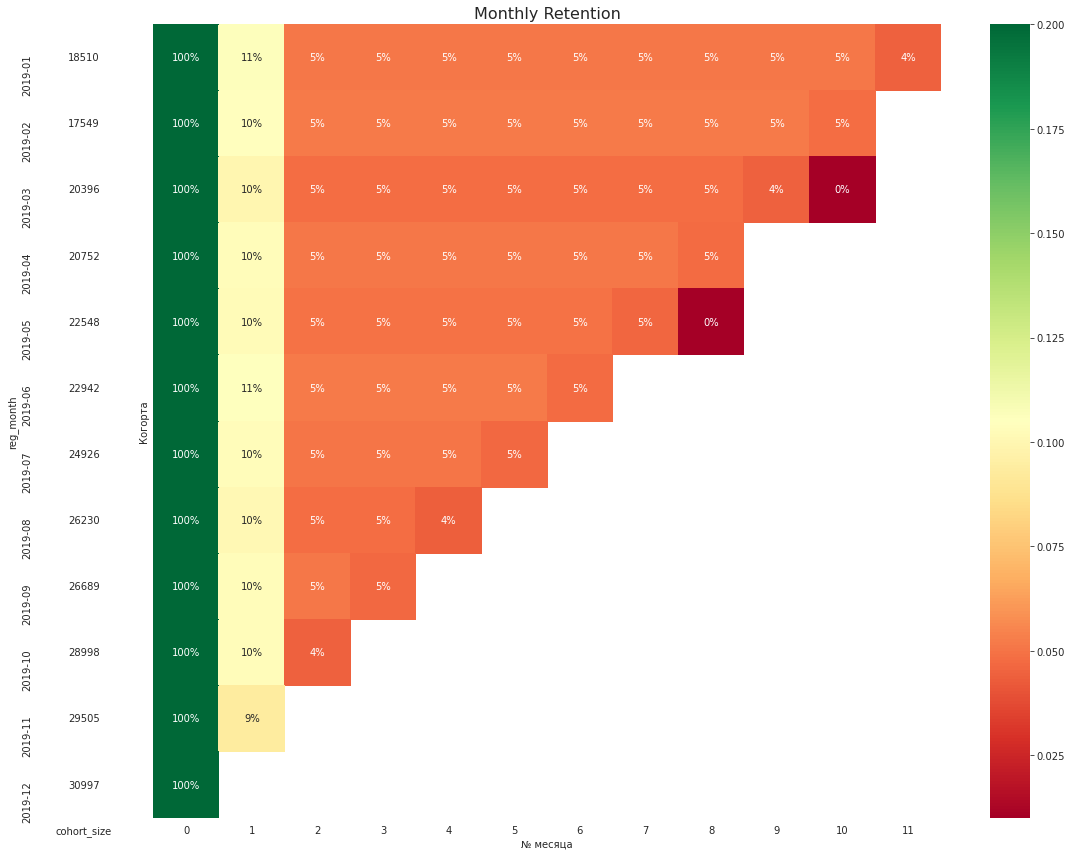

In [32]:
# Строим тепловую карту когортного анализа
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    sns.heatmap(cohort_matrix,
                mask=cohort_matrix.isnull(),
                annot=True,
                fmt='.0%',
                cmap='RdYlGn',
                vmin=0.01,
                vmax=0.2,
                ax=ax[1])
    ax[1].set_title('Monthly Retention', fontsize=16)
    ax[1].set(xlabel='№ месяца', ylabel='Когорта')

    # Тепловая карта для размеров когорт
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])

    fig.tight_layout()
    plt.show()

In [100]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def retention(df_reg, df_auth, start_date, end_date, time_format='D'):
    """
    Когортный анализ retention с тепловыми картами удержания и размеров когорт.

    :param df_reg: DataFrame с регистрациями ('uid', 'reg_ts')
    :param df_auth: DataFrame с авторизациями ('uid', 'auth_ts')
    :param start_date: Начальная дата ('YYYY-MM-DD')
    :param end_date: Конечная дата ('YYYY-MM-DD')
    :param time_format: 'Y' (год), 'M' (месяц), 'D' (день)
    :return: Две тепловые карты (размер когорты + retention)
    """

    # Преобразуем границы в timestamp
    start_ts = pd.Timestamp(start_date).timestamp()
    end_ts = pd.Timestamp(end_date).timestamp()

    # Фильтруем данные по датам
    df_reg = df_reg[(df_reg['reg_ts'] >= start_ts) & (df_reg['reg_ts'] <= end_ts)].copy()
    df_auth = df_auth[(df_auth['auth_ts'] >= start_ts) & (df_auth['auth_ts'] <= end_ts)].copy()

    # Преобразуем timestamp в datetime
    df_reg['reg_date'] = pd.to_datetime(df_reg['reg_ts'], unit='s')
    df_auth['auth_date'] = pd.to_datetime(df_auth['auth_ts'], unit='s')

    # Объединяем данные по пользователям
    df = df_auth.merge(df_reg, on='uid', how='left')

    # Определяем когорту по дате регистрации
    df['cohort'] = df['reg_date'].dt.to_period(time_format)

    # Определяем период
    if time_format == 'D':
        df['period'] = (df['auth_date'] - df['reg_date']).dt.days
    if time_format == 'M':
        auth_months = df['auth_date'].dt.to_period('M').view('int64')
        reg_months = df['reg_date'].dt.to_period('M').view('int64')
        df['period'] = auth_months - reg_months

    elif time_format == 'Y':
        auth_years = df['auth_date'].dt.to_period('Y').view('int64')
        reg_years = df['reg_date'].dt.to_period('Y').view('int64')
        df['period'] = auth_years - reg_years

    else:
        raise ValueError("time_format должен быть 'D', 'M' или 'Y'")

    # Построение когортной таблицы
    cohort_counts = pd.crosstab(df['cohort'], df['period'], values=df['uid'], aggfunc='nunique').fillna(0)

    # Вычисляем retention
    cohort_sizes = cohort_counts.iloc[:, 0]  # Размеры когорт
    retention_matrix = cohort_counts.div(cohort_sizes, axis=0)  # Делим на первый столбец
    

    # Строим тепловые карты
    with sns.axes_style("white"):
        fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

        # Тепловая карта для коэффициентов удержания
        sns.heatmap(retention_matrix,
                    mask=retention_matrix.isnull(),
                    annot=True,
                    fmt='.0%',
                    cmap='RdYlGn',
                    linewidths=0.5,
                    ax=ax[1])
        ax[1].set_title('Retention', fontsize=16)
        ax[1].set(xlabel='№ периода', ylabel='Когорта')
        
        # Тепловая карта для размеров когорт
        cohort_size_df = pd.DataFrame(cohort_sizes).rename(columns={0: 'cohort_size'})
        white_cmap = mcolors.ListedColormap(['white'])
        sns.heatmap(cohort_size_df,
                    annot=True,
                    cbar=False,
                    fmt='g',
                    cmap=white_cmap,
                    ax=ax[0])

        fig.tight_layout()
        plt.show()


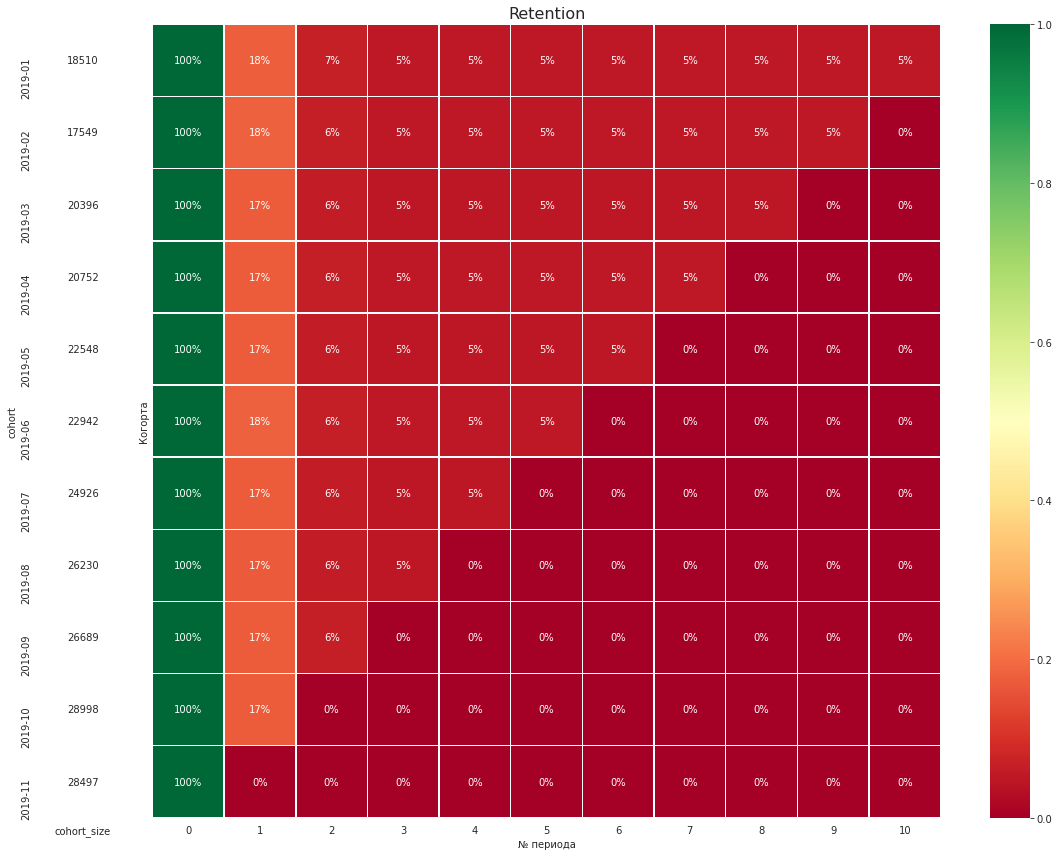

In [101]:
retention(df_reg, df_auth, '2019-01-01', '2019-11-30', 'M')

# Вывод
В ходе работы возникли проблемы, если функцию писать, как планировалсь в тестовом варианте, то данные обрабатывались бы слишком долго, поэтому, я подумал, сначала лучше работать с таймстепом и убрать лишние данные, оставив те, которые входят в наш диапазон а только потом преобразовывать в дату

# Задание 2
Имеются результаты A/B теста, в котором двум группам пользователей предлагались различные наборы акционных предложений. Известно, что ARPU в тестовой группе выше на 5%, чем в контрольной. При этом в контрольной группе 1928 игроков из 202103 оказались платящими, а в тестовой – 1805 из 202667.

Какой набор предложений можно считать лучшим? Какие метрики стоит проанализировать для принятия правильного решения и как?

In [35]:
df_stat = pd.read_csv('Проект_1_Задание_2.csv', sep=';')

In [36]:
df_stat.groupby('testgroup', as_index=False) \
    .agg({'revenue': 'count'})

,testgroup,revenue
0,a,202103
1,b,202667


In [37]:
df_stat.revenue.sort_values(ascending=False).head(10)

101861    37433
196601    37407
65077     37394
21585     37385
142804    37379
229054    37374
174390    37369
175825    37366
76986     37363
287698    37360
Name: revenue, dtype: int64

In [38]:
df_stat.groupby(['revenue', 'testgroup'], as_index=False) \
    .agg({'user_id': 'count'}) \
    .sort_values(by='revenue', ascending=False) \
    .head(50)

,revenue,testgroup,user_id
1477,37433,a,1
1476,37407,a,1
1475,37394,a,1
1474,37385,a,1
1473,37379,a,1
1472,37374,a,1
1471,37369,a,1
1470,37366,a,1
1469,37363,a,1
1468,37360,a,1


In [39]:
df_stat.isna().sum()

user_id      0
revenue      0
testgroup    0
dtype: int64

In [40]:
df_stat.groupby(['revenue', 'testgroup'], as_index=False).agg({'user_id': 'count'})

,revenue,testgroup,user_id
0,0,a,200175
1,0,b,200862
2,200,a,8
3,201,a,8
4,202,a,10
...,...,...,...
1473,37379,a,1
1474,37385,a,1
1475,37394,a,1
1476,37407,a,1


In [41]:
df_stat_non_zero = df_stat.query('revenue != 0')

In [42]:
df_stat_non_zero.groupby('testgroup', as_index=False).agg({'revenue': 'count'})

,testgroup,revenue
0,a,1928
1,b,1805


# План
Сначала проверим конверсию в платящих пользователей

Затем посмотрим на средний чек платящих в каждой группе (ARPPU) 

В заключение посмотрим различатются ли CR и ARPU с помощью t теста или хи квадрат


In [57]:
grouped = df_stat.groupby("testgroup", as_index=False)["revenue"]

summary = (
    grouped.agg(["count", "sum", "mean"])
    .rename(columns={"count": "users", "sum": "total_revenue", "mean": "ARPU"})
)


In [59]:
paying_users = df_stat[df_stat["revenue"] > 0].groupby("testgroup")["user_id"].count()

In [60]:
summary["paying_users"] = paying_users
summary["CR"] = summary["paying_users"] / summary["users"]
summary["ARPPU"] = summary["total_revenue"] / summary["paying_users"]

In [61]:
summary

,users,total_revenue,ARPU,paying_users,CR,ARPPU
testgroup,,,,,,
a,202103,5136189,25.413720,1928,0.009540,2663.998444
b,202667,5421603,26.751287,1805,0.008906,3003.658172


In [47]:
paying_users.b

1805

# ПРАВКИ


In [86]:
group_A = df_stat[df_stat['testgroup'] == 'a']['revenue']
group_B = df_stat[df_stat['testgroup'] == 'b']['revenue']


In [80]:
group_A_nonzero = group_A[group_A != 0]
group_B_nonzero = group_B[group_B != 0]

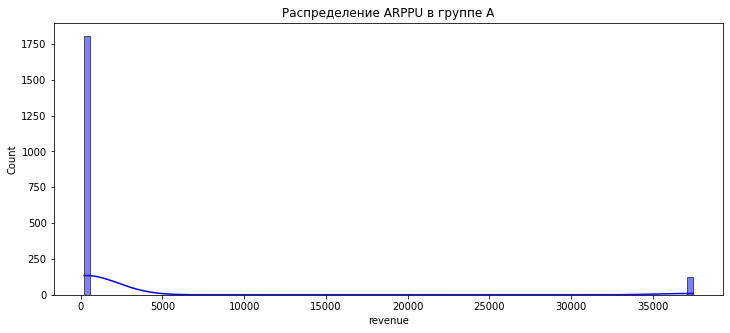

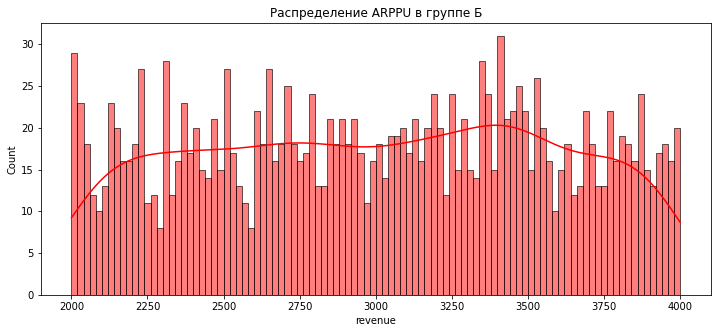

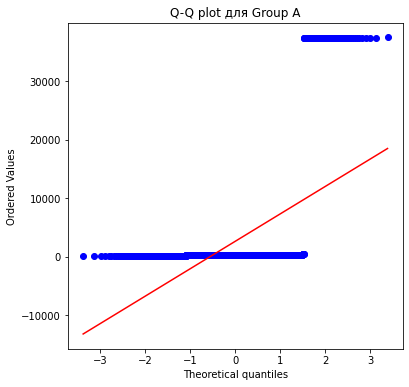

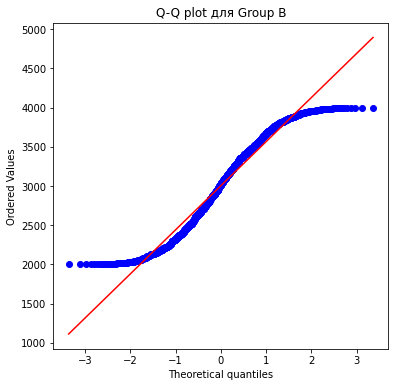

In [85]:
plt.figure(figsize=(12, 5))
sns.histplot(group_A_nonzero, bins=100, color="blue", kde=True,)
plt.title("Распределение ARPPU в группе A")
plt.show()

plt.figure(figsize=(12, 5))
sns.histplot(group_B_nonzero, bins=100, color="red", kde=True,)
plt.title("Распределение ARPPU в группе Б")
plt.show()


plt.figure(figsize=(6, 6))
stats.probplot(group_A_nonzero, dist="norm", plot=plt)
plt.title("Q-Q plot для Group A")
plt.show()


plt.figure(figsize=(6, 6))
stats.probplot(group_B_nonzero, dist="norm", plot=plt)
plt.title("Q-Q plot для Group B")
plt.show()

Хотя распределение данных не является нормальным, мы используем t-тест, потому что размер выборки в каждой группе достаточно велик (>200 тыс.). Согласно центральной предельной теореме, распределение средних значений ARPU при таком объеме данных будет стремиться к нормальному, что делает применение t-теста оправданным.


Как мы видим в тестовой группе средний чек на платящего пользователя значительно выше 



# Проверяем значимость разницы ARPU (T-тест)
H0: ARPU в группах A и B одинаковый.

H1: ARPU в группе B отличается от A.

In [48]:
from scipy import stats

# Разделяем данные по группам
arpu_a = df_stat[df_stat["testgroup"] == "a"]["revenue"]
arpu_b = df_stat[df_stat["testgroup"] == "b"]["revenue"]

# T-тест
t_stat_arpu, p_value_arpu = stats.ttest_ind(arpu_a, arpu_b, equal_var=False)

print(f"T-test для ARPU: t-статистика = {t_stat_arpu:.4f}, p-значение = {p_value_arpu:.4f}")


T-test для ARPU: t-статистика = -0.6235, p-значение = 0.5330


# Проверяем значимость разницы CR (Z-тест)
H0: Конверсия в платежи (CR) одинакова в обеих группах.

H1: Конверсия в группе B отличается от A.

Исправил ошибку: так как конверсия — это отношение числа платящих пользователей к общему числу пользователей, правильнее сравнивать доли в этих группах. 

In [93]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

paying_a = summary.loc["a", "paying_users"]
total_a = summary.loc["a", "users"]

paying_b = summary.loc["b", "paying_users"]
total_b = summary.loc["b", "users"]

# Количество платящих пользователей и размер выборки
counts = np.array([paying_a, paying_b])
nobs = np.array([total_a, total_b])

# Z-тест
z_stat, p_value_z = proportions_ztest(counts, nobs)

print(f"Z-тест для конверсии: Z-статистика = {z_stat:.4f}, p-значение = {p_value_z:.4f}")


Z-тест для конверсии: Z-статистика = 2.1080, p-значение = 0.0350


# Проверяем значимость разницы ARPPU (T-тест)

H0: Средний ARPPU в группах одинаковый.

H1: Средний ARPPU в группе B отличается.

In [50]:
# Отфильтруем только платящих пользователей
arppu_a = df_stat[(df_stat["testgroup"] == "a") & (df_stat["revenue"] > 0)]["revenue"]
arppu_b = df_stat[(df_stat["testgroup"] == "b") & (df_stat["revenue"] > 0)]["revenue"]

# T-тест
t_stat_arppu, p_value_arppu = stats.ttest_ind(arppu_a, arppu_b, equal_var=False)

print(f"T-test для ARPPU: t-статистика = {t_stat_arppu:.4f}, p-значение = {p_value_arppu:.4f}")


T-test для ARPPU: t-статистика = -1.6446, p-значение = 0.1002


Как мы видим стат значимых различей нет, но есть один нюанс в контрольной группе больше дорогих оплат, это может быть связано с чем угодно, если речь идет про игру, возможно сезонное предложение или выгодный набор, и тестовая группа просто не успела на эти предложения

Я предлогаю провести тест без учета сезонных покупок, сначала посмотрим сколько вообще таких покупок

In [51]:
df_stat.query('revenue > 30000').groupby('testgroup').agg({'revenue': 'count'})

,revenue
testgroup,
a,123


In [52]:
df_stat.query('revenue > 1000').groupby('testgroup').agg({'revenue': 'count'})

,revenue
testgroup,
a,123
b,1805


In [53]:
df_stat.query('revenue > 100').groupby('testgroup').agg({'revenue': 'count'})

,revenue
testgroup,
a,1928
b,1805


Уже на этом этапе мы можем заметить, что основную вырочку для контрольной группы делают 123 человека которые соверешли покупки свыше 30 тыс 

Text(0, 0.5, 'Группа')

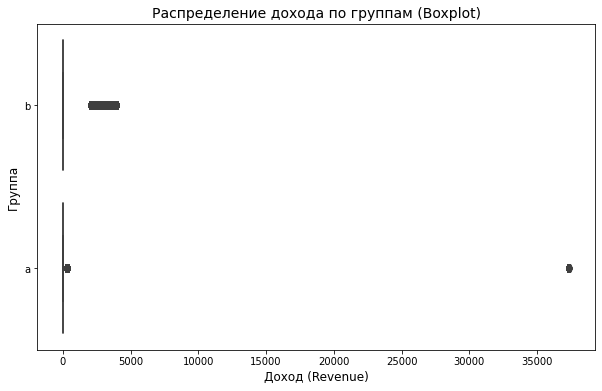

In [54]:

plt.figure(figsize=(10, 6))
sns.boxplot(x="revenue", y="testgroup", data=df_stat) 

# Добавляем заголовок
plt.title("Распределение дохода по группам (Boxplot)", fontsize=14)
plt.xlabel("Доход (Revenue)", fontsize=12)
plt.ylabel("Группа", fontsize=12)


In [55]:
# Ограничиваем revenue в группе "A" до 30 000
df_filtered = df_stat.copy()
df_filtered.loc[(df_filtered["testgroup"] == "a") & (df_filtered["revenue"] > 30000), "revenue"] = 0
df_filtered

,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b
...,...,...,...
404765,404766,0,a
404766,404767,0,b
404767,404768,231,a
404768,404769,0,a


In [56]:
arpu_a_filtered = df_filtered[df_filtered["testgroup"] == "a"]["revenue"]
arpu_b_filtered = df_filtered[df_filtered["testgroup"] == "b"]["revenue"]

arppu_a_filtered = df_filtered[(df_filtered["testgroup"] == "a") & (df_filtered["revenue"] > 0)]["revenue"]
arppu_b_filtered = df_filtered[(df_filtered["testgroup"] == "b") & (df_filtered["revenue"] > 0)]["revenue"]


t_stat_arpu_filtered, p_value_arpu_filtered = stats.ttest_ind(arpu_a_filtered, arpu_b_filtered, equal_var=False)

t_stat_arppu_filtered, p_value_arppu_filtered = stats.ttest_ind(arppu_a_filtered, arppu_b_filtered, equal_var=False)

print(
    f"T-test для ARPU: t-статистика = {t_stat_arpu_filtered:.4f}, "
    f"p-значение = {p_value_arpu_filtered:.4f}"
)
print(
    f"T-test для ARPPU: t-статистика = {t_stat_arppu_filtered:.4f}, "
    f"p-значение = {p_value_arppu_filtered:.4f}"
)


T-test для ARPU: t-статистика = -37.4913, p-значение = 0.0000
T-test для ARPPU: t-статистика = -199.3972, p-значение = 0.0000


# Итог исправленный
Как мы видим стат значения есть что нас не может не радоавать, остается правда нюанс, если наша теория не верна, о том что дорогостоющие покупки в контрольной группе были сезонными, то мы ошиблись... 

Я согласен, что 123 человека составляют основную платящую массу в контрольной группе. Возможно, их исключение было не самым разумным решением. В такой ситуации правильнее либо проводить A/B-тест заново, либо детально анализировать, что это были за покупки и кто их совершил. Возможно, мы сравниваем разные группы клиентов — например, в тестовой группе находятся новые пользователи, а в контрольной — постоянные или ВИП-клиенты. В любом случае делать радикальные выводы, как я изначально сделал, было поспешным. Гораздо важнее разобраться во всех нюансах, чтобы не искажать результаты. Сейчас лучше оставить всё как есть, поскольку различия наблюдаются только в конверсии остальные различия случайны — коневрсия оказалась ниже в тестовой группе


# Задание 3

В первую очередь это Retention Rate, мы должны понимать сколько пользователей вернулось во время ивента

Также можно посмотреть сколько людей вообще приняли участие в ивенте доля активных игроков, которые приняли участие в событии.

Также можно посмотреть пришли ли к нам новые игроки из за ивента, и остались после его завершения 

Если в нашей игре присутствует монитизация во время ивента чаще всего это БП то можем посмотреть ARPU и ARPPU

# Если мы добаляем механику отката

Нужно учитывать количество людей которые вышли из игры из за сложности в прохождении уровня

Но эта механика может плохо сказаться на наших игроках, если игра давольно казуальная и не является каким то вызовом для трайхардеров, то это будет провально, лучше всего провести А\Б тест и понять нужно ли это нашим игрокам или нет. 

Если результат окажется положительным и людям зайдет это обновление в целом останется все также, если есть возможность пропустить откат за валюту, важно смотреть, выросли ли платежи



# Важно!
Важно понимать на что мы хотим делать упор, для чего этот ивент, привлечение новых пользователей или увеличить монетизацию, в зависмости от цели выбирать нужные нам метрики
